
## AVA Training System — Laboratoires Vital

**Business Objective:** Improve the learning quality of medical representatives before real field visits.  
**Data Science Objective:** Analyze and score spoken medical interactions using NLP to provide feedback.

---
**Datasets:**
- `ava_training_dataset_vital_COMPLET.json` — AVA Q&A training dataset (170 entries)
- `parapharmacie_vital_dynamic.json` — Parapharmacie product catalog (265 entries)

---

# 📑 Table of Contents

---

## 🏥 BO1 — AVA Training System (Laboratoires Vital)
> *Improve learning quality of medical representatives before real field visits*

| # | Section |
|---|---|
| 0 | Imports & Setup |
| 1 | Load Datasets |
| **Dataset 1 — AVA Training Dataset** | |
| 2 | Overview & Schema |
| 3 | Missing Values |
| 4 | Distribution by Category |
| 5 | Difficulty Level & AVA Profile |
| 6 | Text Length Analysis |
| 7 | Top Keywords in Questions & Key Elements |
| **Dataset 2 — Parapharmacie Catalog** | |
| 8 | Overview & Schema |
| 9 | Missing Values |
| 10 | Product Categories |
| 11 | Price Analysis |
| 12 | Ratings & Reviews Analysis |
| 13 | Product Text Completeness |
| 14 | Top Keywords in Descriptions |
| 15 | BO1 Data Quality Summary |

---

## 📣 BO4 — Audience Segmentation for Targeted Marketing
> *Build an unsupervised segmentation system with LLMs (text) and diffusion models (images)*

| # | Section |
|---|---|
| **Dataset — vital_with_reviews.json** | |
| BO4.1 | Load Dataset |
| BO4.2 | Overview & Schema |
| BO4.3 | Missing Values & Data Quality |
| BO4.4 | Review Volume Distribution |
| BO4.5 | Rating Analysis |
| BO4.6 | Review Text Analysis & Sentiment Proxy |
| BO4.7 | Top Keywords by Sentiment (Audience Signals) |
| BO4.8 | Reviewer Profiles (Segmentation Signals) |
| BO4.9 | Product Segmentation by Gamme |
| BO4.10 | NLP Readiness Assessment |
| BO4.11 | BO4 Data Quality Summary |

---

## 🏥 BO5 — CRM Medical Visits — Segmentation & Targeting
> *Optimize medical representative visit strategy through data-driven segmentation*

| # | Section |
|---|---|
| **Dataset — vital_bo6_datasetProduit.json** | |
| BO5.0 | Import & Load Data |
| BO5.1 | Data Overview |
| BO5.2 | Distribution des Spécialités |
| BO5.3 | Distribution Géographique |
| BO5.4 | Objections Principales |
| BO5.5 | Sentiment & Interest Analysis |
| BO5.6 | Analyse des Catégories Produits |
| BO5.7 | Segmentation Prête pour LLM |
| BO5.8 | Segmentation par Spécialité × Intérêt |
| BO5.9 | Engagement par Canal (Clinic / Hospital / Pharmacy) |
| BO5.10 | Heatmap Région × Engagement |
| BO5.11 | Top Produits par Niveau d'Intérêt |

---


# 🏥 BO1 — Data Acquisition & Understanding

## 📦 0. Imports & Setup

In [ ]:
# ===============================
# IMPORTS
# ===============================
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ===============================
# STYLE & VISUAL SETTINGS
# ===============================

# Taille des figures
plt.rcParams['figure.figsize'] = (12, 5)

# Police propre et lisible
plt.rcParams['font.family'] = 'DejaVu Sans'

# Thème seaborn
sns.set_theme(style='whitegrid')

# Palette personnalisée (AVA style)
TEAL = '#009688'
GREEN = '#4CAF50'
BLUE = '#2F748E'
LIGHT_BG = '#F4FBFF'

sns.set_palette([TEAL, GREEN, BLUE])

# ===============================
# TEST VISUEL (optionnel)
# ===============================
print("✅ All imports successful")

✅ All imports successful


## 📂 1. Load Datasets

In [ ]:
# ⚠️ Update paths if needed
AVA_PATH = 'ava_training_dataset_vital_COMPLET.json'
PARA_PATH = 'parapharmacie_vital_dynamic.json'

with open(AVA_PATH, encoding='utf-8') as f:
    ava_raw = json.load(f)

with open(PARA_PATH, encoding='utf-8') as f:
    para_raw = json.load(f)

df_ava = pd.DataFrame(ava_raw)
df_para = pd.DataFrame(para_raw)

print(f'✅ AVA Dataset    : {df_ava.shape[0]} rows × {df_ava.shape[1]} columns')
print(f'✅ Parapharmacie  : {df_para.shape[0]} rows × {df_para.shape[1]} columns')

✅ AVA Dataset    : 170 rows × 16 columns
✅ Parapharmacie  : 265 rows × 49 columns


---
## 🤖 DATASET 1 — AVA Training Dataset
## 2. Overview & Schema

In [ ]:
print('=== AVA Dataset — First 3 rows ===')
df_ava.head(3)

=== AVA Dataset — First 3 rows ===


,id,categorie,sous_categorie,profil_ava,niveau_difficulte,question_ava,reponse_attendue_delegue,elements_cles,feedback_si_mauvaise_reponse,source_data,mode_ava,produit_reference,gamme,produits_references,contre_indications_mentionner,produits_prioritaires
0,Q001,Présentation produit,Découverte gamme,Pharmacien d'officine,Facile,"Bonjour, vous représentez les Laboratoires Vit...",Bonjour Docteur/Madame. Les Laboratoires Vital...,"[Vitonic, Pédiakids, Oligovit, Omevie, Phytoth...",Vous n'avez pas mentionné les gammes clés. Un ...,vital.com.tn + parapharmacie.tn + paraexpert.tn,Mode 1 - Training & Simulation,NaN,NaN,NaN,NaN,NaN
1,Q002,Présentation produit,Découverte gamme,Médecin généraliste,Facile,"Vital, c'est surtout des compléments alimentai...",Vital couvre les deux domaines. En compléments...,"[compléments alimentaires, dermo-cosmétique, H...",Réponse incomplète. Vital est positionné sur l...,vital.com.tn + parapharmacie.tn + paraexpert.tn,Mode 1 - Training & Simulation,NaN,NaN,NaN,NaN,NaN
2,Q003,Présentation produit,Produit spécifique,Gynécologue obstétricien,Moyen,Vous voulez me parler d'un produit pour mes pa...,"Je vous propose Vitonic Grossesse, un compléme...","[OMS, Oméga-3, Fer, Vitamine B9, Iode, 1 gélul...",Vous avez oublié de mentionner la référence OM...,vital.com.tn + parapharmacie.tn + paraexpert.tn,Mode 1 - Training & Simulation,Vitonic Grossesse,Vitonic,NaN,NaN,NaN


In [ ]:
print('=== Schema & Data Types ===')
df_ava.info()

=== Schema & Data Types ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   id                             170 non-null    object
 1   categorie                      170 non-null    object
 2   sous_categorie                 170 non-null    object
 3   profil_ava                     170 non-null    object
 4   niveau_difficulte              170 non-null    object
 5   question_ava                   170 non-null    object
 6   reponse_attendue_delegue       170 non-null    object
 7   elements_cles                  107 non-null    object
 8   feedback_si_mauvaise_reponse   43 non-null     object
 9   source_data                    170 non-null    object
 10  mode_ava                       170 non-null    object
 11  produit_reference              73 non-null     object
 12  gamme                          1 non

In [ ]:
# ==========================================
# FEATURE SUMMARY TABLE (Data Understanding)
# ==========================================

summary = []

for col in df_ava.columns:

    # Détecter un exemple non nul
    sample = df_ava[col].dropna().iloc[0] if df_ava[col].notna().any() else None

    # Détecter listes/dicts
    if isinstance(sample, (list, dict)):
        unique_vals = "lists/dicts"
    else:
        unique_vals = df_ava[col].nunique()

    # valeurs manquantes
    missing_count = df_ava[col].isna().sum()
    missing_pct = round((missing_count / len(df_ava)) * 100, 1)

    summary.append([
        col,
        df_ava[col].dtype,
        unique_vals,
        missing_count,
        f"{missing_pct}%"
    ])

import pandas as pd

summary_df = pd.DataFrame(
    summary,
    columns=[
        "Feature",
        "Type",
        "Unique Values",
        "Missing Values",
        "Missing %"
    ]
)

summary_df

,Feature,Type,Unique Values,Missing Values,Missing %
0,id,object,170,0,0.0%
1,categorie,object,10,0,0.0%
2,sous_categorie,object,93,0,0.0%
3,profil_ava,object,25,0,0.0%
4,niveau_difficulte,object,4,0,0.0%
5,question_ava,object,170,0,0.0%
6,reponse_attendue_delegue,object,170,0,0.0%
7,elements_cles,object,lists/dicts,63,37.1%
8,feedback_si_mauvaise_reponse,object,43,127,74.7%
9,source_data,object,2,0,0.0%


### 3. Missing Values — AVA Dataset

                               Missing Count  Missing %
id                                         0       0.00
categorie                                  0       0.00
sous_categorie                             0       0.00
profil_ava                                 0       0.00
niveau_difficulte                          0       0.00
question_ava                               0       0.00
reponse_attendue_delegue                   0       0.00
elements_cles                             63      37.06
feedback_si_mauvaise_reponse             127      74.71
source_data                                0       0.00
mode_ava                                   0       0.00
produit_reference                         97      57.06
gamme                                    169      99.41
produits_references                       89      52.35
contre_indications_mentionner            169      99.41
produits_prioritaires                    169      99.41


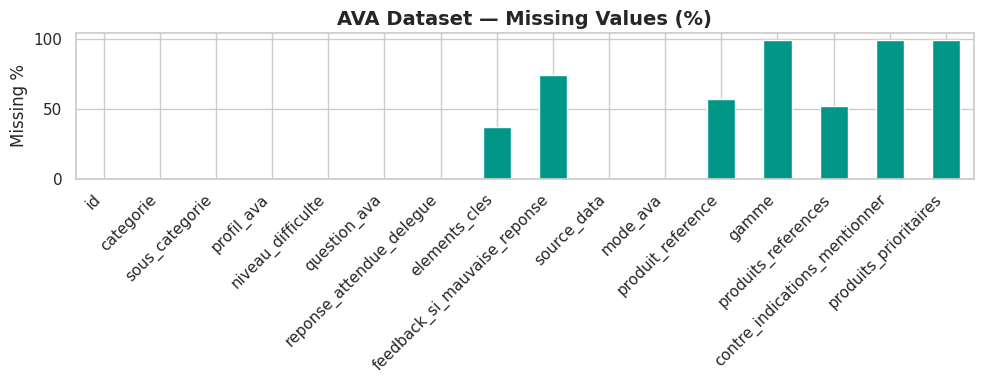

In [ ]:
missing = df_ava.isnull().sum()
missing_pct = (missing / len(df_ava) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 4))
missing_pct.plot(kind='bar', color=TEAL, ax=ax)
ax.set_title('AVA Dataset — Missing Values (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Distribution by Category — AVA Dataset

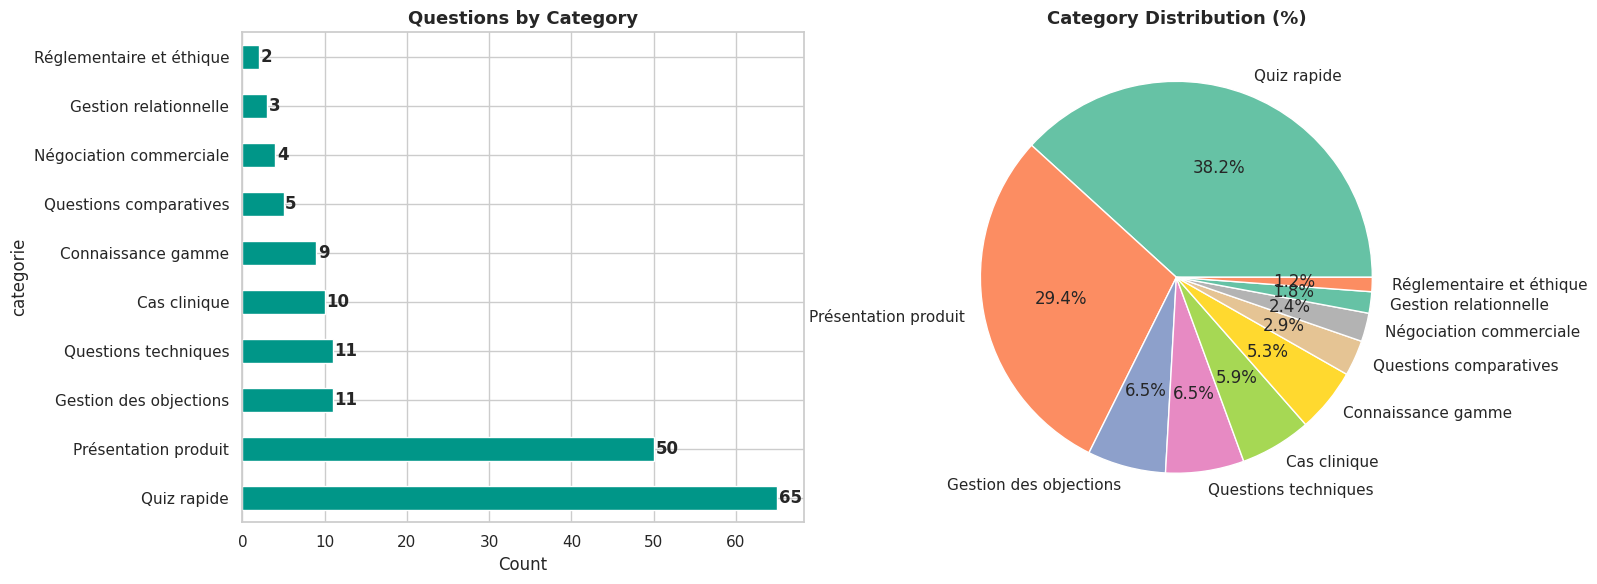

In [ ]:
cat_counts = df_ava['categorie'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
cat_counts.plot(kind='barh', ax=axes[0], color=TEAL)
axes[0].set_title('Questions by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 0.2, i, str(v), va='center', fontweight='bold')

# Pie chart
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(cat_counts)))
axes[1].set_title('Category Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

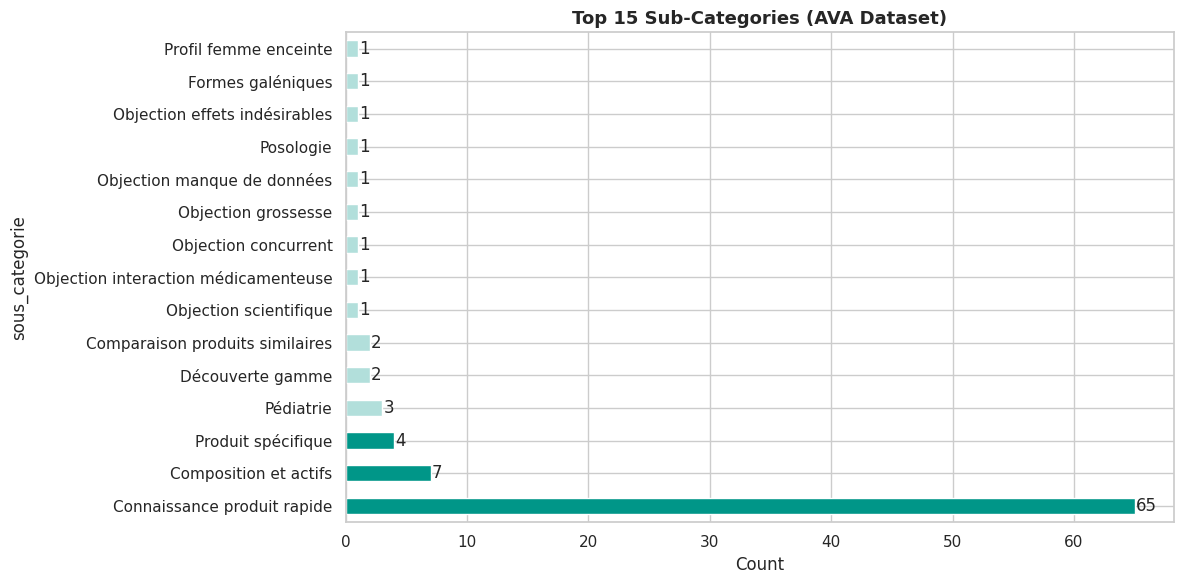

In [ ]:
sous_cat = df_ava['sous_categorie'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = [TEAL if i < 3 else '#B2DFDB' for i in range(len(sous_cat))]
sous_cat.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 15 Sub-Categories (AVA Dataset)', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
for i, v in enumerate(sous_cat.values):
    ax.text(v + 0.1, i, str(v), va='center')
plt.tight_layout()
plt.show()

### 5. Difficulty Level & Profil AVA

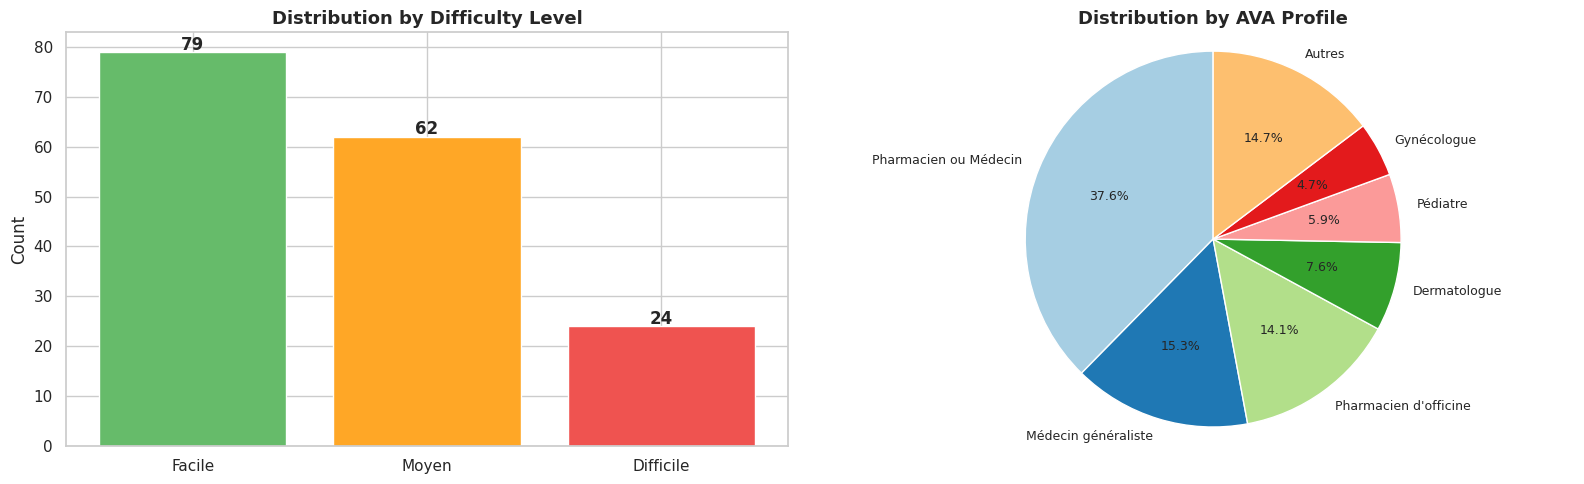

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# =========================
# 1️⃣ Difficulty Distribution
# =========================
diff_order = ['Facile', 'Moyen', 'Difficile']
diff_counts = df_ava['niveau_difficulte'].value_counts().reindex(diff_order, fill_value=0)

colors_diff = ['#66BB6A', '#FFA726', '#EF5350']

bars = axes[0].bar(diff_counts.index, diff_counts.values, color=colors_diff)

axes[0].set_title('Distribution by Difficulty Level', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# afficher les valeurs au-dessus des barres
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        str(int(bar.get_height())),
        ha='center',
        fontweight='bold'
    )

# =========================
# 2️⃣ AVA Profile Distribution (clean)
# =========================

top_n = 6  # nombre de profils principaux à afficher

profil_counts = df_ava['profil_ava'].value_counts()

top_profiles = profil_counts[:top_n]
others = profil_counts[top_n:].sum()

profil_final = top_profiles.copy()
profil_final['Autres'] = others

axes[1].pie(
    profil_final,
    labels=profil_final.index,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize':9},
    colors=sns.color_palette('Paired', len(profil_final))
)

axes[1].set_title('Distribution by AVA Profile', fontsize=13, fontweight='bold')
axes[1].axis('equal')  # cercle parfait

plt.tight_layout()
plt.show()

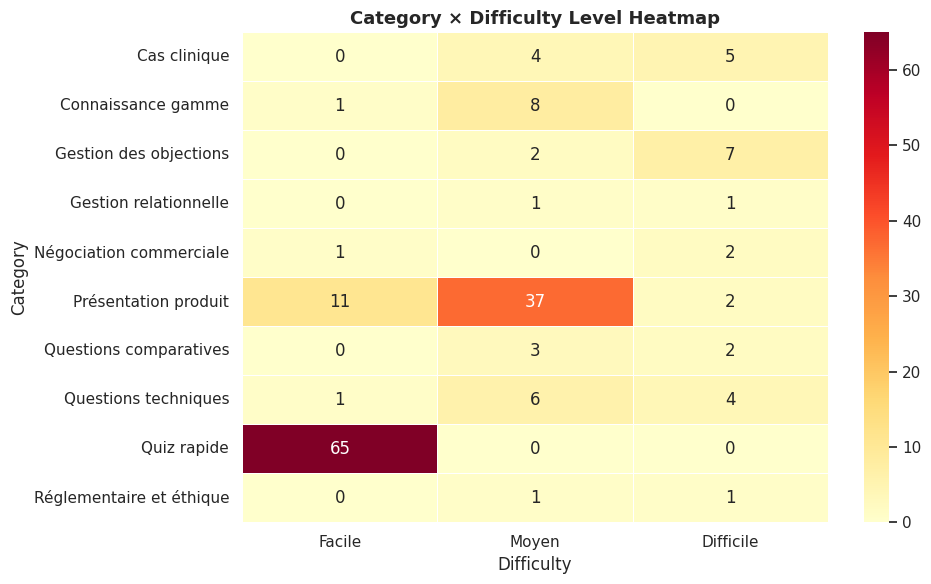

In [ ]:
# Heatmap: Category × Difficulty
heatmap_data = df_ava.groupby(['categorie', 'niveau_difficulte']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(columns=diff_order, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Category × Difficulty Level Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Difficulty')
ax.set_ylabel('Category')
plt.tight_layout()
plt.show()

### 6. Text Length Analysis — AVA Dataset

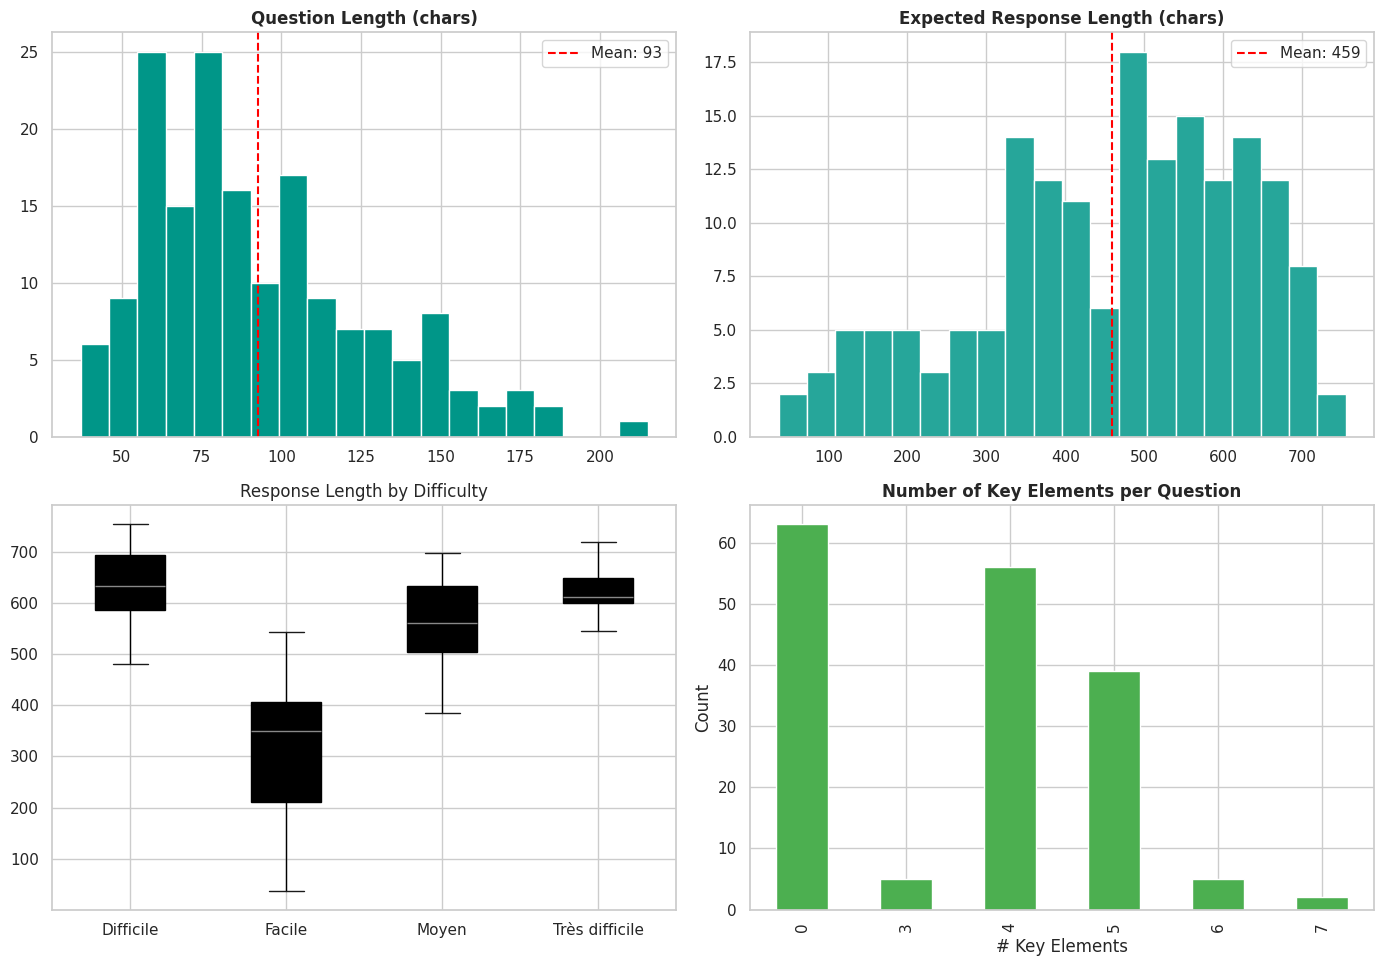


📊 Text Length Statistics:


,len_question,len_reponse,len_feedback,nb_elements_cles
count,170.0,170.0,170.0,170.0
mean,92.6,458.6,33.3,2.8
std,35.3,168.7,53.5,2.2
min,37.0,37.0,3.0,0.0
25%,64.2,357.2,3.0,0.0
50%,84.5,490.0,3.0,4.0
75%,110.0,586.5,57.8,5.0
max,215.0,755.0,178.0,7.0


In [ ]:
df_ava['len_question'] = df_ava['question_ava'].astype(str).apply(len)
df_ava['len_reponse'] = df_ava['reponse_attendue_delegue'].astype(str).apply(len)
df_ava['len_feedback'] = df_ava['feedback_si_mauvaise_reponse'].astype(str).apply(len)
df_ava['nb_elements_cles'] = df_ava['elements_cles'].apply(lambda x: len(x) if isinstance(x, list) else 0)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_ava['len_question'], bins=20, color=TEAL, edgecolor='white')
axes[0, 0].set_title('Question Length (chars)', fontweight='bold')
axes[0, 0].axvline(df_ava['len_question'].mean(), color='red', linestyle='--', label=f"Mean: {df_ava['len_question'].mean():.0f}")
axes[0, 0].legend()

axes[0, 1].hist(df_ava['len_reponse'], bins=20, color='#26A69A', edgecolor='white')
axes[0, 1].set_title('Expected Response Length (chars)', fontweight='bold')
axes[0, 1].axvline(df_ava['len_reponse'].mean(), color='red', linestyle='--', label=f"Mean: {df_ava['len_reponse'].mean():.0f}")
axes[0, 1].legend()

# Box plots by difficulty
df_ava.boxplot(column='len_reponse', by='niveau_difficulte', ax=axes[1, 0], patch_artist=True)
axes[1, 0].set_title('Response Length by Difficulty', fontweight='bold')
axes[1, 0].set_xlabel('')
plt.sca(axes[1, 0])
plt.title('Response Length by Difficulty')

# Elements cles
df_ava['nb_elements_cles'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color=GREEN)
axes[1, 1].set_title('Number of Key Elements per Question', fontweight='bold')
axes[1, 1].set_xlabel('# Key Elements')
axes[1, 1].set_ylabel('Count')

plt.suptitle('')
plt.tight_layout()
plt.show()

print('\n📊 Text Length Statistics:')
df_ava[['len_question', 'len_reponse', 'len_feedback', 'nb_elements_cles']].describe().round(1)

### 7. Most Frequent Keywords in Questions & Key Elements

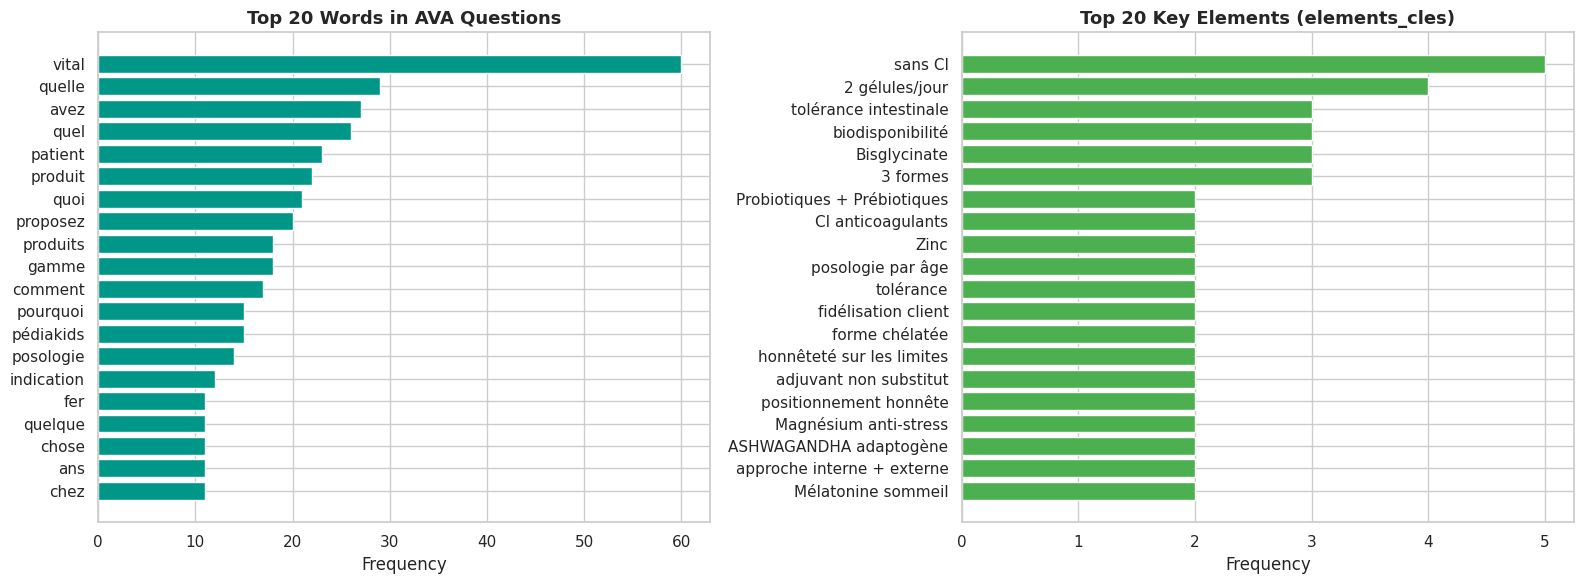

In [ ]:
import re

STOPWORDS_FR = {'le','la','les','de','du','des','et','en','à','au','aux','un','une','je','vous',
                'que','qui','pour','sur','avec','par','dans','est','se','ne','pas','plus','ce',
                'son','sa','nous','il','ils','elle','elles','mon','votre','leur','leurs','me',
                'on','si','ou','mais','donc','car','ni','or','the','of','and','to','is','in'}

def tokenize(texts):
    tokens = []
    for t in texts:
        words = re.findall(r"[a-zA-ZÀ-ÿ]{3,}", str(t).lower())
        tokens.extend([w for w in words if w not in STOPWORDS_FR])
    return tokens

q_tokens = tokenize(df_ava['question_ava'])
q_freq = Counter(q_tokens).most_common(20)

all_elements = []
for row in df_ava['elements_cles']:
    if isinstance(row, list):
        all_elements.extend(row)
elem_freq = Counter(all_elements).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top words in questions
words_q, counts_q = zip(*q_freq)
axes[0].barh(list(reversed(words_q)), list(reversed(counts_q)), color=TEAL)
axes[0].set_title('Top 20 Words in AVA Questions', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')

# Top key elements
words_e, counts_e = zip(*elem_freq)
axes[1].barh(list(reversed(words_e)), list(reversed(counts_e)), color=GREEN)
axes[1].set_title('Top 20 Key Elements (elements_cles)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()

---
## 💊 DATASET 2 — Parapharmacie Product Catalog
# 9. Overview & Schema

In [ ]:
print('=== Parapharmacie Dataset — First 3 rows ===')
df_para.head(3)

=== Parapharmacie Dataset — First 3 rows ===


,product_url,name,prix,prix_original,note,nb_avis,categories,image_url,highlights,indications,...,dermadouce_savon_huile_d_amandes_douces_90_g,contenu_de_la_trousse,error,un_soutien_doux_pour_le_bien_etre_nocturne,cosmopharma_vital_vaseline_pommade_40_g,calmoss_gorge_menthe_complement_alimentaire_respiratoire,calmoss_gorge_cassis_complement_alimentaire,calmoss_gorge_eucalyptus_complement_alimentaire,complement_alimentaire_comprimes_a_croquer_au_carbonate_de_calcium,calmoss_constipation_complement_alimentaire
0,https://parapharmacie.tn/shop/complements-alim...,Vital Oligovit Zinc Bt/15 Gelules,6.269 TND,7.557 TND,Note 4.40 sur 5,5,Compléments Alimentaires | Confort | Zinc,https://parapharmacie.tn/wp-content/uploads/20...,Oligovit ZINC | Améliore les défenses immunita...,Booste le système immunitaire | Traitement de ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://parapharmacie.tn/shop/complements-alim...,Omevie Omega 3 – 1000 30 Capsules,31.345 TND,37.785 TND,Note 4.64 sur 5,11,Compléments Alimentaires | Confort | Omega 3,https://parapharmacie.tn/wp-content/uploads/20...,Complément alimentaire | Equilibre émotionnel ...,Contribue au bon développement cérébral | Main...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://parapharmacie.tn/shop/complements-alim...,Vital Oligovit Vitamine C Bt/30,5.821 TND,7.017 TND,Note 4.58 sur 5,24,Compléments Alimentaires | Confort | Anti fatigue,https://parapharmacie.tn/wp-content/uploads/20...,VITAL OLIGOVIT VITAMINE C | Complément aliment...,Fatigue | Asthénie | Courbatures | Baisse d’im...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_para.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 49 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   product_url                                                          265 non-null    object
 1   name                                                                 264 non-null    object
 2   prix                                                                 264 non-null    object
 3   prix_original                                                        264 non-null    object
 4   note                                                                 76 non-null     object
 5   nb_avis                                                              263 non-null    object
 6   categories                                                           264 non-null    object
 7   image_url        

In [ ]:
# Convert numeric fields
df_para['prix_num'] = pd.to_numeric(df_para['prix'].astype(str).str.replace(',', '.').str.extract(r'([\d.]+)')[0], errors='coerce')
df_para['prix_original_num'] = pd.to_numeric(df_para['prix_original'].astype(str).str.replace(',', '.').str.extract(r'([\d.]+)')[0], errors='coerce')
df_para['note_num'] = pd.to_numeric(df_para['note'].astype(str).str.extract(r'([\d.]+)')[0], errors='coerce')
df_para['nb_avis_num'] = pd.to_numeric(df_para['nb_avis'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

df_para[['prix_num', 'prix_original_num', 'note_num', 'nb_avis_num']].describe().round(2)

,prix_num,prix_original_num,note_num,nb_avis_num
count,264.00,264.00,76.00,263.00
mean,19.94,24.04,4.41,5.11
std,14.75,17.80,0.53,10.21
min,4.03,4.86,2.00,1.00
25%,10.45,12.60,4.00,1.00
50%,16.43,19.80,4.45,2.00
75%,24.65,29.72,5.00,6.00
max,119.41,143.94,5.00,116.00


### 10. Missing Values — Parapharmacie Dataset

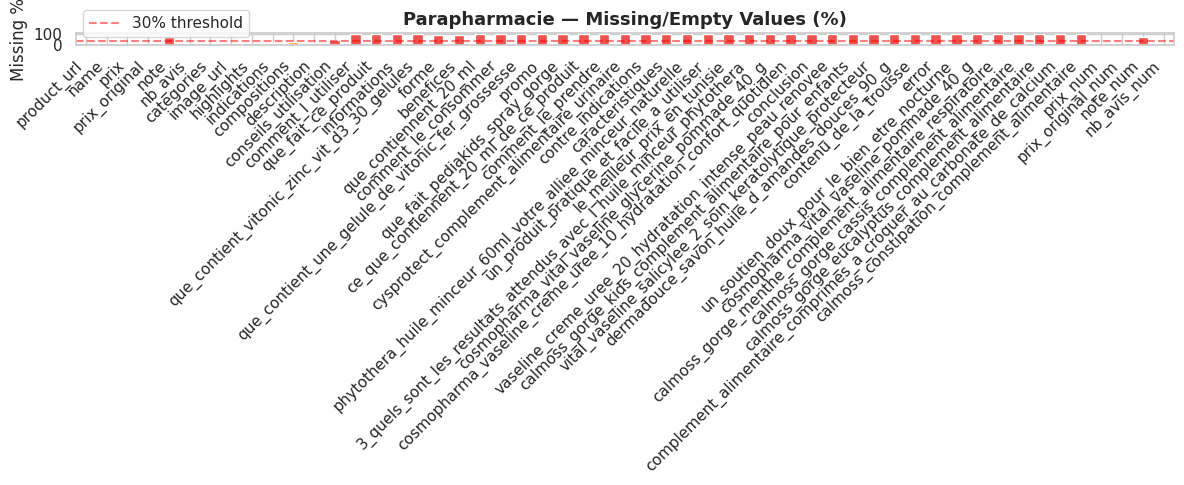


Missing counts:


,Count,Percentage %
product_url,0,0.0
name,1,0.4
prix,1,0.4
prix_original,1,0.4
note,189,71.3
nb_avis,2,0.8
categories,1,0.4
image_url,1,0.4
highlights,1,0.4
indications,37,14.0


In [ ]:
# Check for missing/empty values
def is_empty(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return True
    if isinstance(val, str) and val.strip() in ['', 'N/A', 'nan', 'None']:
        return True
    if isinstance(val, list) and len(val) == 0:
        return True
    return False

missing_para = {col: df_para[col].apply(is_empty).sum() for col in df_para.columns}
missing_para_s = pd.Series(missing_para)
missing_para_pct = (missing_para_s / len(df_para) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#EF5350' if v > 30 else '#FFA726' if v > 10 else TEAL for v in missing_para_pct.values]
missing_para_pct.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Parapharmacie — Missing/Empty Values (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing %')
ax.axhline(30, color='red', linestyle='--', alpha=0.5, label='30% threshold')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nMissing counts:')
pd.DataFrame({'Count': missing_para_s, 'Percentage %': missing_para_pct})

### 11. Product Categories

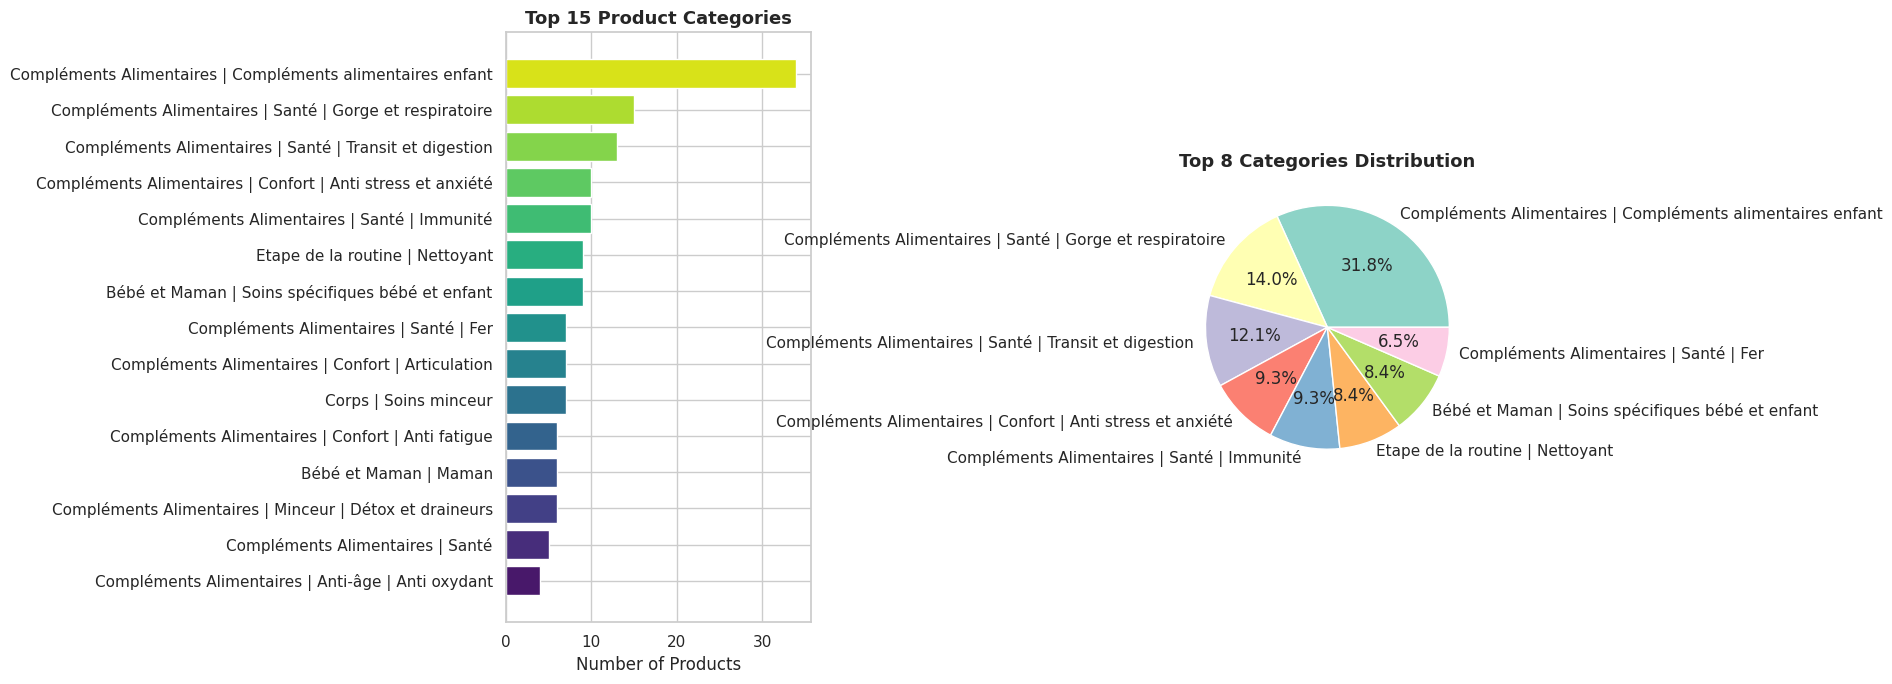

Total unique categories: 67


In [ ]:
# Flatten categories
all_cats = []
for cats in df_para['categories']:
    if isinstance(cats, list):
        all_cats.extend(cats)
    elif isinstance(cats, str) and cats:
        all_cats.append(cats)

cat_freq = Counter(all_cats).most_common(20)
cat_names, cat_vals = zip(*cat_freq) if cat_freq else ([], [])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(list(reversed(cat_names[:15])), list(reversed(cat_vals[:15])),
             color=sns.color_palette('viridis', 15))
axes[0].set_title('Top 15 Product Categories', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Products')

# Pie for top 8
axes[1].pie(cat_vals[:8], labels=cat_names[:8], autopct='%1.1f%%',
            colors=sns.color_palette('Set3', 8))
axes[1].set_title('Top 8 Categories Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Total unique categories: {len(set(all_cats))}')

### 12. Price Analysis

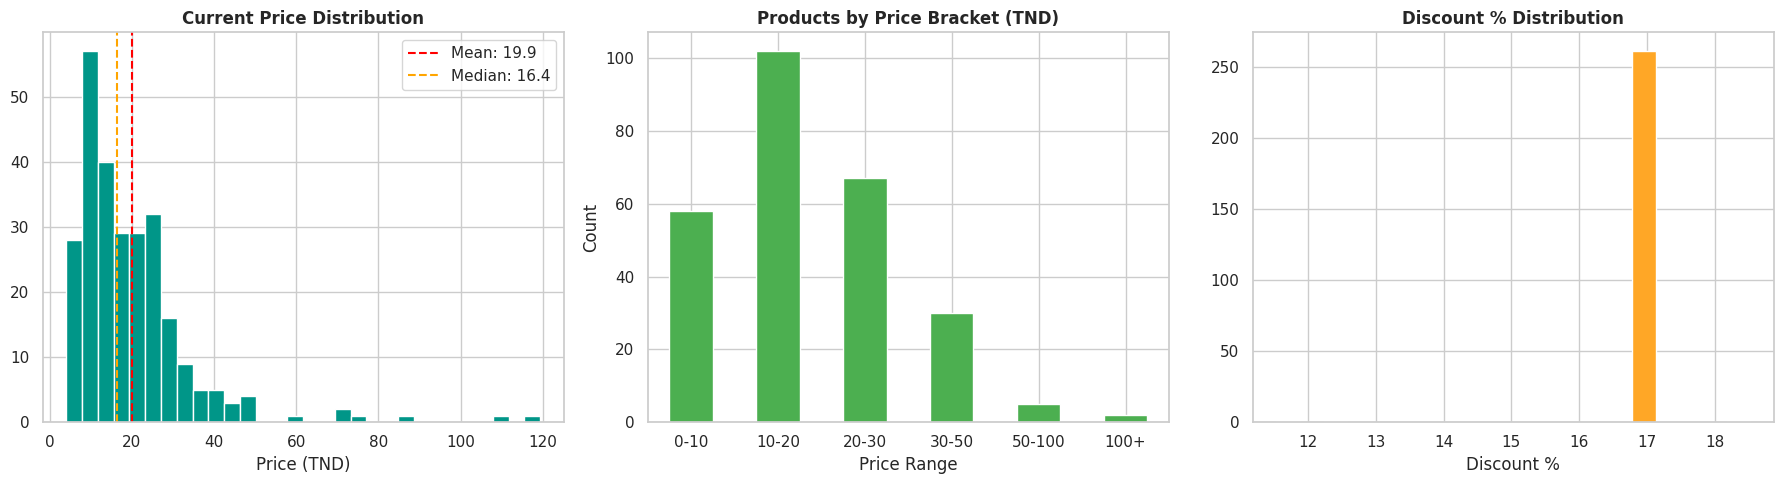


💰 Price Stats (TND):
count    264.00
mean      19.94
std       14.75
min        4.03
25%       10.45
50%       16.43
75%       24.65
max      119.41
Name: prix_num, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price distribution
prix_clean = df_para['prix_num'].dropna()
axes[0].hist(prix_clean, bins=30, color=TEAL, edgecolor='white')
axes[0].axvline(prix_clean.mean(), color='red', linestyle='--', label=f'Mean: {prix_clean.mean():.1f}')
axes[0].axvline(prix_clean.median(), color='orange', linestyle='--', label=f'Median: {prix_clean.median():.1f}')
axes[0].set_title('Current Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (TND)')
axes[0].legend()

# Price brackets
bins = [0, 10, 20, 30, 50, 100, 9999]
labels = ['0-10', '10-20', '20-30', '30-50', '50-100', '100+']
df_para['price_bracket'] = pd.cut(df_para['prix_num'], bins=bins, labels=labels)
bracket_counts = df_para['price_bracket'].value_counts().sort_index()
bracket_counts.plot(kind='bar', ax=axes[1], color=GREEN)
axes[1].set_title('Products by Price Bracket (TND)', fontweight='bold')
axes[1].set_xlabel('Price Range')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

# Price vs original price (discount analysis)
df_both = df_para.dropna(subset=['prix_num', 'prix_original_num'])
df_both = df_both[df_both['prix_original_num'] > 0]
if len(df_both) > 0:
    df_both['discount_pct'] = ((df_both['prix_original_num'] - df_both['prix_num']) / df_both['prix_original_num'] * 100).clip(0, 100)
    axes[2].hist(df_both['discount_pct'], bins=20, color='#FFA726', edgecolor='white')
    axes[2].set_title('Discount % Distribution', fontweight='bold')
    axes[2].set_xlabel('Discount %')
else:
    axes[2].text(0.5, 0.5, 'No discount data available', ha='center', va='center')
    axes[2].set_title('Discount Analysis', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n💰 Price Stats (TND):')
print(prix_clean.describe().round(2))

### 13. Ratings & Reviews Analysis

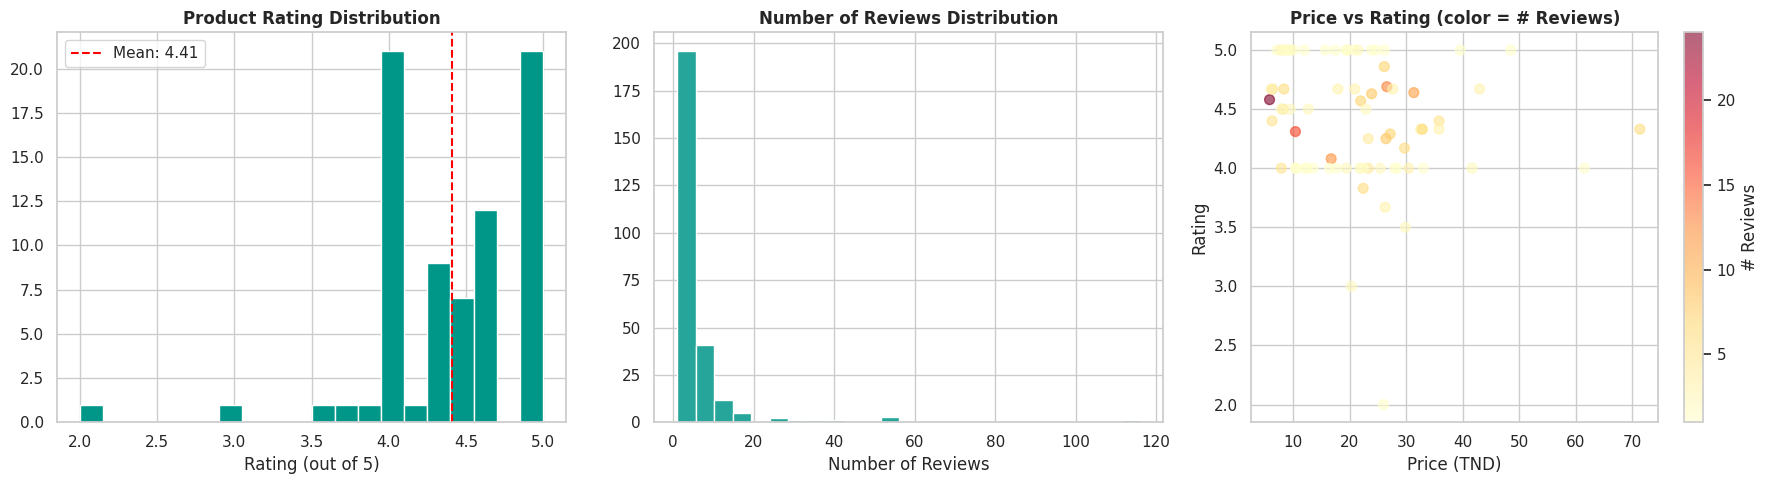


⭐ Ratings with data: 76/265 (28.7%)
Average rating: 4.41/5


In [ ]:
note_clean = df_para['note_num'].dropna()
avis_clean = df_para['nb_avis_num'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Rating distribution
axes[0].hist(note_clean, bins=20, color=TEAL, edgecolor='white')
axes[0].axvline(note_clean.mean(), color='red', linestyle='--', label=f'Mean: {note_clean.mean():.2f}')
axes[0].set_title('Product Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating (out of 5)')
axes[0].legend()

# Number of reviews
axes[1].hist(avis_clean, bins=25, color='#26A69A', edgecolor='white')
axes[1].set_title('Number of Reviews Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Reviews')

# Rating vs price scatter
df_rated = df_para.dropna(subset=['note_num', 'prix_num'])
sc = axes[2].scatter(df_rated['prix_num'], df_rated['note_num'],
                     c=df_rated['nb_avis_num'].fillna(0),
                     cmap='YlOrRd', alpha=0.6, s=50)
plt.colorbar(sc, ax=axes[2], label='# Reviews')
axes[2].set_title('Price vs Rating (color = # Reviews)', fontweight='bold')
axes[2].set_xlabel('Price (TND)')
axes[2].set_ylabel('Rating')

plt.tight_layout()
plt.show()

print(f'\n⭐ Ratings with data: {len(note_clean)}/{len(df_para)} ({len(note_clean)/len(df_para)*100:.1f}%)')
print(f'Average rating: {note_clean.mean():.2f}/5')

### 14. Product Text Completeness

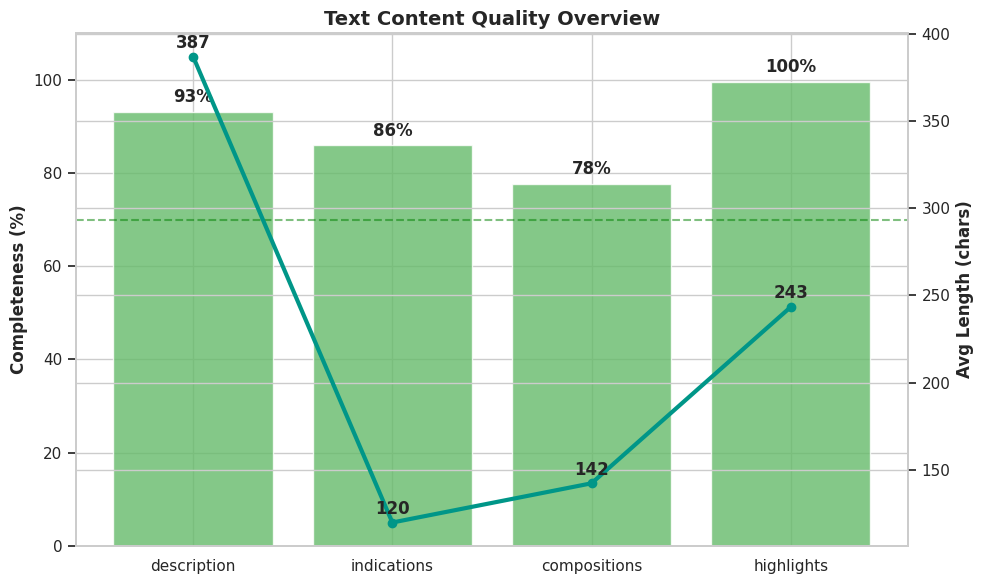

In [ ]:
# ===============================
# TEXT QUALITY OVERVIEW (ONE GRAPH)
# ===============================

text_cols = ['description', 'indications', 'compositions', 'highlights']

def text_length(val):
    if pd.isna(val):
        return 0
    if isinstance(val, list):
        return sum(len(str(v)) for v in val)
    return len(str(val))

stats = []

for col in text_cols:
    if col in df_para.columns:
        filled = df_para[col].apply(lambda x: text_length(x) > 5).sum()
        completeness = filled / len(df_para) * 100
        avg_len = df_para[col].apply(text_length).mean()
        stats.append((col, completeness, avg_len))

stats_df = pd.DataFrame(stats, columns=['Field', 'Completeness (%)', 'Avg Length'])

# ===============================
# Plot
# ===============================
fig, ax1 = plt.subplots(figsize=(10,6))

# Bars = completeness
bars = ax1.bar(stats_df['Field'], stats_df['Completeness (%)'],
               color='#66BB6A', alpha=0.8)

ax1.set_ylabel('Completeness (%)', fontweight='bold')
ax1.set_ylim(0, 110)
ax1.axhline(70, linestyle='--', color='green', alpha=0.5, label='Quality threshold (70%)')

# Second axis for text length
ax2 = ax1.twinx()
ax2.plot(stats_df['Field'], stats_df['Avg Length'],
         marker='o', linewidth=3)

ax2.set_ylabel('Avg Length (chars)', fontweight='bold')

# Labels on bars
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 2,
             f'{h:.0f}%', ha='center', fontweight='bold')

# Labels on line points
for i, v in enumerate(stats_df['Avg Length']):
    ax2.text(i, v + 5, f'{v:.0f}', ha='center', fontweight='bold')

plt.title('Text Content Quality Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()